In [ ]:
import glob, os
#for f in glob.glob("/content/drive/MyDrive/LISN_Project/checkpoints/*.pth"):
  os.remove(f)
  print(f"Deleted: {os.path.basename(f)}")

Deleted: lisn_epoch_0020.pth
Deleted: lisn_epoch_0040.pth
Deleted: lisn_best.pth
Deleted: lisn_epoch_0060.pth
Deleted: lisn_epoch_0080.pth
Deleted: lisn_epoch_0100.pth


In [ ]:
"""
LISN — Lightweight Information Split Network
Infrared Image Super-Resolution + YOLOv8 Detection
====================================================

Drive structure:
  MyDrive/LISN_Project/
    repo/
    datasets/
      flir_adas/           ← raw FLIR download
      IR_SR/               ← generated HR/LR pairs
    checkpoints/           ← saved model weights
    results/               ← metrics CSV + figures

Notebook sections:
  1. Environment     [every session]
  2. Drive setup     [every session]
  3. Downloads       [once only]
  4. Dataset prep    [once only]
  5. Train           [once, ~2-5h on T4]
  6. Inference       [as needed]
  7. YOLOv8          [as needed]
  8. Visualization   [as needed]
"""

'\nLISN — Lightweight Information Split Network\nInfrared Image Super-Resolution + YOLOv8 Detection\n====================================================\n\nDrive structure:\n  MyDrive/LISN_Project/\n    repo/\n    datasets/\n      flir_adas/           ← raw FLIR download\n      IR_SR/               ← generated HR/LR pairs\n    checkpoints/           ← saved model weights\n    results/               ← metrics CSV + figures\n\nNotebook sections:\n  1. Environment     [every session]\n  2. Drive setup     [every session]\n  3. Downloads       [once only]\n  4. Dataset prep    [once only]\n  5. Train           [once, ~2-5h on T4]\n  6. Inference       [as needed]\n  7. YOLOv8          [as needed]\n  8. Visualization   [as needed]\n'

============================================================
SECTION 1 — Environment Setup  [Every Session]
============================================================

In [ ]:
# --- 1.1 GPU check ---
#@title 1.1 — GPU Verification [Every Session]
import torch
print("=" * 50)
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU: {gpu}  ({mem:.1f} GB)")
    print(f"  CUDA: {torch.version.cuda}  PyTorch: {torch.__version__}")
    DEVICE = 'cuda'
else:
    print("  WARNING: No GPU. Go to Runtime > Change runtime type > GPU")
    DEVICE = 'cpu'
print("=" * 50)

  GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition  (102.0 GB)
  CUDA: 12.8  PyTorch: 2.10.0+cu128


In [ ]:
# --- 1.2 Dependencies ---
#@title 1.2 — Install Dependencies [Every Session]
get_ipython().system('pip install -q scikit-image opencv-python-headless ultralytics pandas matplotlib')
print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.9 MB/s eta 0:00:00
Dependencies installed.


============================================================
SECTION 2 — Google Drive Setup  [Every Session]
============================================================

In [ ]:
#@title 2.1 — Mount Drive & Configure Paths [Every Session]
import os, sys
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DRIVE_ROOT = "/content/drive/MyDrive/LISN_Project"

In [ ]:
PATHS = {
    'root':        DRIVE_ROOT,
    'repo':        f"{DRIVE_ROOT}/repo",
    'flir_raw':    f"{DRIVE_ROOT}/datasets/flir_adas",
    'flir_data':   f"{DRIVE_ROOT}/datasets/flir_adas/FLIR_ADAS_1_3",
    'train_hr':    f"{DRIVE_ROOT}/datasets/IR_SR/train/HR",
    'train_lr4':   f"{DRIVE_ROOT}/datasets/IR_SR/train/LR_x4",
    'test_hr':     f"{DRIVE_ROOT}/datasets/IR_SR/test/HR",
    'test_lr2':    f"{DRIVE_ROOT}/datasets/IR_SR/test/LR_x2",
    'test_lr4':    f"{DRIVE_ROOT}/datasets/IR_SR/test/LR_x4",
    'test_sr2':    f"{DRIVE_ROOT}/datasets/IR_SR/test/SR_x2",
    'test_sr4':    f"{DRIVE_ROOT}/datasets/IR_SR/test/SR_x4",
    'checkpoints': f"{DRIVE_ROOT}/checkpoints",
    'results':     f"{DRIVE_ROOT}/results",
    'figures':     f"{DRIVE_ROOT}/results/figures",
}

In [ ]:
for p in PATHS.values():
    os.makedirs(p, exist_ok=True)

In [ ]:
# Add repo to Python path
sys.path.insert(0, PATHS['repo'])
os.chdir(PATHS['repo'])

In [ ]:
print("Drive mounted. Paths configured.")
print(f"Working directory: {os.getcwd()}")

Drive mounted. Paths configured.
Working directory: /content/drive/MyDrive/LISN_Project/repo


In [ ]:
#@title 2.2 — Verify Assets [Every Session]
checks = {
    'Repo (models/lisn.py)': f"{PATHS['repo']}/models/lisn.py",
    'FLIR dataset':          PATHS['flir_data'],
    'Train HR':              PATHS['train_hr'],
    'Train LR×4':            PATHS['train_lr4'],
    'Test HR':               PATHS['test_hr'],
    'Test LR×4':             PATHS['test_lr4'],
    'Checkpoints':           PATHS['checkpoints'],
}
print("Asset check:")
for name, path in checks.items():
    exists = os.path.exists(path)
    count = ""
    if os.path.isdir(path) and exists:
        n = len(os.listdir(path))
        count = f" ({n} items)"
    status = "OK" + count if exists else "MISSING"
    print(f"  {'✓' if exists else '✗'} {name:<25s} {status}")

Asset check:
  ✓ Repo (models/lisn.py)     OK
  ✓ FLIR dataset              OK (6 items)
  ✓ Train HR                  OK (8862 items)
  ✓ Train LR×4                OK (8862 items)
  ✓ Test HR                   OK (1195 items)
  ✓ Test LR×4                 OK (1194 items)
  ✓ Checkpoints               OK (16 items)


============================================================
SECTION 3 — One-Time Downloads  [Once Only]
============================================================

@title 3.1 — Upload Repo to Drive [Once Only]
INSTRUCTION: Upload the clean repo folder to MyDrive/LISN_Project/repo/
You only need to do this once. The folder should contain:
  models/lisn.py, models/losses.py, data/dataset.py,
  utils/metrics.py, utils/prepare_dataset.py,
  train.py, inference.py

In [ ]:
repo_check = f"{PATHS['repo']}/models/lisn.py"
if os.path.exists(repo_check):
    print("Repo already on Drive. Contents:")
    get_ipython().system(f'find {PATHS["repo"]} -name "*.py" | sort')
else:
    print("REPO NOT FOUND on Drive.")
    print("Upload the repo/ folder to: MyDrive/LISN_Project/repo/")
    print("Then re-run this cell.")

Repo already on Drive. Contents:
/content/drive/MyDrive/LISN_Project/repo/data/dataset.py
/content/drive/MyDrive/LISN_Project/repo/data/__init__.py
/content/drive/MyDrive/LISN_Project/repo/inference.py
/content/drive/MyDrive/LISN_Project/repo/models/__init__.py
/content/drive/MyDrive/LISN_Project/repo/models/lisn.py
/content/drive/MyDrive/LISN_Project/repo/models/losses.py
/content/drive/MyDrive/LISN_Project/repo/old version/dataset.py
/content/drive/MyDrive/LISN_Project/repo/old version/train.py
/content/drive/MyDrive/LISN_Project/repo/train.py
/content/drive/MyDrive/LISN_Project/repo/utils/__init__.py
/content/drive/MyDrive/LISN_Project/repo/utils/metrics.py
/content/drive/MyDrive/LISN_Project/repo/utils/prepare_dataset.py


In [ ]:
#@title 3.2 — Download FLIR ADAS Dataset [Once Only]
if os.path.exists(PATHS['flir_data']):
    print(f"FLIR dataset exists. Skipping.")
    get_ipython().system(f'ls "{PATHS["flir_data"]}"')
else:
    # Configure Kaggle
    from google.colab import files
    kaggle_path = '/root/.kaggle/kaggle.json'
    if not os.path.exists(kaggle_path):
        print("Upload kaggle.json:")
        uploaded = files.upload()
        os.makedirs('/root/.kaggle', exist_ok=True)
        get_ipython().system('mv kaggle.json /root/.kaggle/ && chmod 600 /root/.kaggle/kaggle.json')

    os.chdir(PATHS['flir_raw'])
    print("Downloading FLIR ADAS (~15 GB, ~20 min)...")
    get_ipython().system('kaggle datasets download -d deepnewbie/flir-thermal-images-dataset')
    get_ipython().system('unzip -o -q flir-thermal-images-dataset.zip')
    get_ipython().system('rm flir-thermal-images-dataset.zip')
    os.chdir(PATHS['repo'])
    print("Done.")

============================================================
SECTION 4 — Dataset Preparation  [Once Only]
============================================================

In [ ]:
#@title 4.1 — Generate HR/LR Pairs [Once Only]
from utils.prepare_dataset import prepare_flir_dataset
prepare_flir_dataset(
    flir_root=PATHS['flir_data'],
    output_root=f"{DRIVE_ROOT}/datasets/IR_SR",
)

In [ ]:
# Report
for label, key in [('Train HR', 'train_hr'), ('Train LR×4', 'train_lr4'),
                    ('Test HR', 'test_hr'), ('Test LR×4', 'test_lr4'), ('Test LR×2', 'test_lr2')]:
    n = len(os.listdir(PATHS[key])) if os.path.isdir(PATHS[key]) else 0
    print(f"  {label}: {n} images")

In [ ]:
#@title 4.2 — Visualize Sample HR/LR Pairs [Once Only]
import cv2
import matplotlib.pyplot as plt

In [ ]:
hr_files = sorted(os.listdir(PATHS['test_hr']))[:4]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for col, fname in enumerate(hr_files):
    hr = cv2.imread(f"{PATHS['test_hr']}/{fname}", cv2.IMREAD_GRAYSCALE)
    lr = cv2.imread(f"{PATHS['test_lr4']}/{fname}", cv2.IMREAD_GRAYSCALE)
    axes[0, col].imshow(hr, cmap='gray'); axes[0, col].set_title(f"HR {hr.shape[1]}×{hr.shape[0]}", fontsize=9); axes[0, col].axis('off')
    axes[1, col].imshow(lr, cmap='gray'); axes[1, col].set_title(f"LR×4 {lr.shape[1]}×{lr.shape[0]}", fontsize=9); axes[1, col].axis('off')
plt.suptitle('HR vs LR×4 — Bicubic Downsampling', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PATHS['figures']}/hr_lr_pairs.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from models.lisn import build_lisn
model = build_lisn(upscale=4, embed_dim=128, num_lisb=8).to('cuda')
p = sum(pp.numel() for pp in model.parameters())
x = torch.randn(1, 1, 32, 32).to('cuda')
with torch.no_grad():
    y = model(x)
print(f"Params: {p:,} ({p/1e3:.1f}K) | {tuple(x.shape)} → {tuple(y.shape)}")
del model, x, y
torch.cuda.empty_cache()

Params: 658,576 (658.6K) | (1, 1, 32, 32) → (1, 1, 128, 128)


============================================================
SECTION 5 — Training  [Once, ~2-5 hours on T4]
============================================================

In [ ]:
#@title 5.1 — Model Sanity Check [Every Session before training]
import torch, sys

sys.path.insert(0, "/content/drive/MyDrive/LISN_Project/repo")
from models.lisn import build_lisn

DEVICE = 'cuda'

# Current config: scaled up for FLIR ADAS
model = build_lisn(upscale=4, embed_dim=128, num_lisb=8).to(DEVICE)
p = sum(pp.numel() for pp in model.parameters())
x = torch.randn(1, 1, 64, 64).to(DEVICE)
with torch.no_grad():
    y = model(x)
print(f"LISN: {p:,} params ({p/1e3:.1f}K) | {tuple(x.shape)} → {tuple(y.shape)} ✓")

del model, x, y
torch.cuda.empty_cache()

LISN: 658,576 params (658.6K) | (1, 1, 64, 64) → (1, 1, 256, 256) ✓


In [ ]:
#@title 5.2 — Train LISN [Once — saves checkpoints to Drive]
NUM_EPOCHS = 500
BATCH_SIZE = 8
SAVE_EVERY = 20

from train import train
model = train(
    train_hr=PATHS['train_hr'],
    train_lr=PATHS['train_lr4'],
    checkpoint_dir=PATHS['checkpoints'],
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    save_every=SAVE_EVERY,
    embed_dim=128,
    num_lisb=8,
    scale=4,
)

Model: LISN | Params: 658,576 (658.6K) | Device: cuda
Dataset: 35448 images | Batch: 8 | Patches: 128×128

Training epochs 1 → 500
LR schedule: CosineAnnealingWarmRestarts (T_0=250, min_lr=1e-6)

  Epoch [   1/500] Loss: 0.111032  Time: 2159.7s  LR: 2.00e-04
  Epoch [  10/500] Loss: 0.034709  Time: 292.9s  LR: 1.99e-04
  Epoch [  20/500] Loss: 0.034201  Time: 294.1s  LR: 1.97e-04
  → Saved: lisn_epoch_0020.pth
  Epoch [  30/500] Loss: 0.034078  Time: 291.7s  LR: 1.93e-04
  Epoch [  40/500] Loss: 0.033959  Time: 284.5s  LR: 1.88e-04
  → Saved: lisn_epoch_0040.pth
  Epoch [  50/500] Loss: 0.033851  Time: 285.7s  LR: 1.81e-04
  Epoch [  60/500] Loss: 0.033704  Time: 285.3s  LR: 1.73e-04
  → Saved: lisn_epoch_0060.pth
  Epoch [  70/500] Loss: 0.033720  Time: 286.7s  LR: 1.64e-04


In [ ]:
import glob
files = sorted(glob.glob(f"/content/drive/MyDrive/LISN_Project/checkpoints/lisn_*.pth"))
for f in files:
    print(f)

============================================================
SECTION 6 — SR Inference & Metrics  [As Needed]
============================================================

In [ ]:
#@title 6.1 — Run Inference on Test Set
import glob
from inference import evaluate

In [ ]:
# Find latest checkpoint
ckpt_files = sorted(glob.glob(f"{PATHS['checkpoints']}/lisn_*.pth"))
if not ckpt_files:
    print("No checkpoints found. Train first (Section 5).")
else:
    latest = ckpt_files[-1]
    print(f"Using: {os.path.basename(latest)}")

    df = evaluate(
        weights=latest,
        test_hr=PATHS['test_hr'],
        test_lr=PATHS['test_lr4'],
        output_dir=PATHS['test_sr4'],
        scale=4,
        embed_dim=92,
        num_lisb=6,
        results_csv=f"{PATHS['results']}/sr_metrics_x4.csv",
    )

Using: lisn_epoch_0100.pth
Loaded weights: /content/drive/MyDrive/LISN_Project/checkpoints/lisn_epoch_0100.pth
Processing 1194 test images...

  100/1194 done...
  200/1194 done...
  300/1194 done...
  400/1194 done...
  500/1194 done...
  600/1194 done...
  700/1194 done...
  800/1194 done...
  900/1194 done...
  1000/1194 done...
  1100/1194 done...

  SR Evaluation (×4)
  Images  : 1194
  PSNR    : 28.52 dB
  SSIM    : 0.7012
  Avg time: 7.4 ms
  Saved: /content/drive/MyDrive/LISN_Project/results/sr_metrics_x4.csv


In [ ]:
import cv2, glob, numpy as np
from utils.metrics import compute_psnr_ssim

hr_files = sorted(glob.glob(f"{PATHS['test_hr']}/*.png"))[:100]
psnrs = []
for f in hr_files:
    fname = os.path.basename(f)
    lr = cv2.imread(f"{PATHS['test_lr4']}/{fname}", cv2.IMREAD_GRAYSCALE)
    hr = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    bic = cv2.resize(lr, (hr.shape[1], hr.shape[0]), interpolation=cv2.INTER_CUBIC)
    p, s = compute_psnr_ssim(bic, hr, border=4)
    psnrs.append(p)
print(f"Bicubic baseline: {np.mean(psnrs):.2f} dB")

Bicubic baseline: 26.28 dB


In [ ]:
import cv2
lr = cv2.imread(f"{PATHS['test_lr4']}/{os.listdir(PATHS['test_lr4'])[0]}", cv2.IMREAD_GRAYSCALE)
hr = cv2.imread(f"{PATHS['test_hr']}/{os.listdir(PATHS['test_hr'])[0]}", cv2.IMREAD_GRAYSCALE)
print(f"LR shape: {lr.shape}")
print(f"HR shape: {hr.shape}")
print(f"LR value range: [{lr.min()}, {lr.max()}]")
print(f"HR value range: [{hr.min()}, {hr.max()}]")

# Check what the model actually outputs
import torch
from models.lisn import build_lisn
# Fix: Use embed_dim=128 and num_lisb=8 to match the trained model
model = build_lisn(upscale=4, embed_dim=128, num_lisb=8).to('cuda')
ckpt = torch.load(f"{PATHS['checkpoints']}/lisn_best.pth", map_location='cuda')
model.load_state_dict(ckpt['model'])
model.eval()

lr_t = torch.from_numpy(lr.astype('float32') / 255.0).unsqueeze(0).unsqueeze(0).to('cuda')
with torch.no_grad():
    sr_t = model(lr_t)
print(f"\nModel output range: [{sr_t.min().item():.4f}, {sr_t.max().item():.4f}]")
print(f"Model output shape: {tuple(sr_t.shape)}")

LR shape: (128, 160)
HR shape: (512, 640)
LR value range: [0, 255]
HR value range: [0, 255]

Model output range: [0.0021, 1.0292]
Model output shape: (1, 1, 512, 640)


In [ ]:
#@title 6.2 — Visual Comparison: LR vs Bicubic vs SR vs HR
import cv2
import matplotlib.pyplot as plt
from utils.metrics import compute_psnr_ssim

In [ ]:
def show_comparison(filename, scale=4):
    lr = cv2.imread(f"{PATHS[f'test_lr{scale}']}/{filename}", cv2.IMREAD_GRAYSCALE)
    sr = cv2.imread(f"{PATHS[f'test_sr{scale}']}/{filename}", cv2.IMREAD_GRAYSCALE)
    hr = cv2.imread(f"{PATHS['test_hr']}/{filename}", cv2.IMREAD_GRAYSCALE)
    bic = cv2.resize(lr, (hr.shape[1], hr.shape[0]), interpolation=cv2.INTER_CUBIC)
    if sr.shape != hr.shape:
        sr = cv2.resize(sr, (hr.shape[1], hr.shape[0]))

    p_bic, s_bic = compute_psnr_ssim(bic, hr, border=scale)
    p_sr, s_sr = compute_psnr_ssim(sr, hr, border=scale)

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    for ax, img, title in zip(axes,
        [lr, bic, sr, hr],
        [f'LR ({lr.shape[1]}×{lr.shape[0]})',
         f'Bicubic\n{p_bic:.2f}dB / {s_bic:.4f}',
         f'LISN SR\n{p_sr:.2f}dB / {s_sr:.4f}',
         f'HR ({hr.shape[1]}×{hr.shape[0]})']):
        ax.imshow(img, cmap='gray'); ax.set_title(title); ax.axis('off')
    gain = p_sr - p_bic
    plt.suptitle(f'×{scale} SR — LISN gain: +{gain:.2f} dB', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{PATHS['figures']}/compare_{filename}", dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# Show first 4 results
sr_files = sorted(os.listdir(PATHS['test_sr4']))
if sr_files:
    for f in sr_files[:4]:
        show_comparison(f, scale=4)
else:
    print("No SR images. Run Section 6.1 first.")

Output hidden; open in https://colab.research.google.com to view.

============================================================
SECTION 7 — YOLOv8 Detection Pipeline  [As Needed]
============================================================

In [ ]:
#@title 7.1 — Run YOLOv8 on LR vs SR vs HR
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
yolo = YOLO('yolov8n.pt')  # nano model, fast

In [ ]:
def detect_and_count(image_dir, label, max_images=50):
    """Run YOLOv8 on images, return detection counts."""
    files = sorted(glob.glob(f"{image_dir}/*.png"))[:max_images]
    total_dets = 0
    for f in files:
        results = yolo(f, verbose=False)
        total_dets += len(results[0].boxes)
    avg = total_dets / len(files) if files else 0
    print(f"  {label:12s}: {avg:.1f} avg detections/image ({len(files)} images)")
    return avg

In [ ]:
print("YOLOv8 detection comparison:\n")
avg_lr = detect_and_count(PATHS['test_lr4'], "LR ×4")
avg_sr = detect_and_count(PATHS['test_sr4'], "SR ×4")
avg_hr = detect_and_count(PATHS['test_hr'],  "HR")

YOLOv8 detection comparison:

  LR ×4       : 1.4 avg detections/image (50 images)
  SR ×4       : 3.3 avg detections/image (50 images)
  HR          : 6.2 avg detections/image (50 images)


In [ ]:
print(f"\nSR improves detection by {((avg_sr - avg_lr) / max(avg_lr, 1)) * 100:.1f}% over LR")


SR improves detection by 134.3% over LR


============================================================
SECTION 8 — Summary Visualization  [As Needed]
============================================================

In [ ]:
#@title 8.1 — Results Summary Chart
import pandas as pd
import matplotlib.pyplot as plt

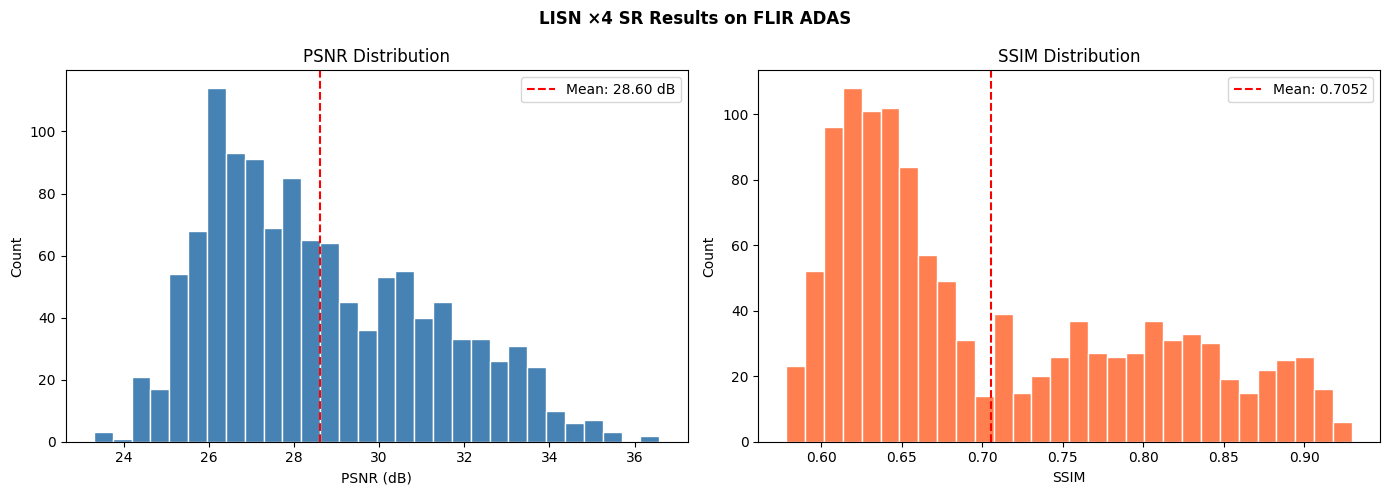

In [ ]:
csv_path = f"{PATHS['results']}/sr_metrics_x4.csv"
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(df['psnr'], bins=30, color='steelblue', edgecolor='white')
    axes[0].axvline(df['psnr'].mean(), color='red', linestyle='--', label=f"Mean: {df['psnr'].mean():.2f} dB")
    axes[0].set_xlabel('PSNR (dB)'); axes[0].set_ylabel('Count'); axes[0].legend()
    axes[0].set_title('PSNR Distribution')

    axes[1].hist(df['ssim'], bins=30, color='coral', edgecolor='white')
    axes[1].axvline(df['ssim'].mean(), color='red', linestyle='--', label=f"Mean: {df['ssim'].mean():.4f}")
    axes[1].set_xlabel('SSIM'); axes[1].set_ylabel('Count'); axes[1].legend()
    axes[1].set_title('SSIM Distribution')

    plt.suptitle('LISN ×4 SR Results on FLIR ADAS', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{PATHS['figures']}/results_summary.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No results CSV found. Run Section 6.1 first.")